# Exercise 6

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
import time

## Part 1


The number of busy lines in a trunk group (Erlang system) follows a truncated Poisson distribution

$$ P(i) = c\frac{A^i}{i!} $$

Generate samples from this distribution using the Metropolis-Hastings algorithm.
- Verify the distribution using a χ2 goodness-of-fit test.
- You may use the parameter values from Exercise 4

We choose   
$h(x,y) = uniform(0,m)$   
since this is symmetric.

We note that:

$f(x)=c*\frac{A^x}{x!}$   
and   
$g(x)=\frac{A^x}{x!}$

The sample space is   
$X \in [0,m]$

The exact pmf distribution is taken as given truncated Poisson dist, normalised by all possibilites
$$ P(i; m, A) = \frac{\frac{A^i}{i!}}{\sum_{k=0}^{m} \frac{A^k}{k!}} $$

In [2]:
#Define theoretical pmf
def truncated_poisson_pmf(i, m, A):
    #normalisation of dist
    norm = 0
    for k in range(0,m+1):
        norm += A**k / math.factorial(k)
        
    numerator = A**i / math.factorial(i)
    return numerator/norm

In [3]:
#Define g(x) function from f(x)=c*g(x)
def g_density(x, A):
    return A**x / math.factorial(x)

#Define proposal function
def h_proposal(m):
    return sp.stats.randint.rvs(low=0,high=m+1)

In [4]:
### Metropolis-Hastings algorithm for Erlang system (system following truncating Poisson distribution)
def MH_Erlang_sys(n_sample, m, A):
    #Convert to int
    n_sample = int(n_sample)

    ## Step 0)
    #Initialise list for samples
    X = []
    #Initialise state x from proposal functionh(x,y)
    x = h_proposal(m)
    X.append(x)

    #Acceptance counter
    accept_count = 0
    #start timing
    start1 = time.time()

    ## Start loop
    for _ in range(n_sample-1):
        ## Step 1)
        #Start from current state
        x = X[-1]
        #Propose candidate state
        y = h_proposal(m)

        ## Step 2)
        #Compute acceptance probability to go from x -> y
        alpha = min(1, g_density(y, A)/g_density(x,A))

        ## Step 3)
        #If accepted, move to y
        if sp.stats.uniform.rvs() <= alpha:
            X.append(y)
            #Count acceptance
            accept_count += 1
        ## Step 4)
        #Otherwise, remain at x (append x again)
        else:
            X.append(x)
 
    #end timing
    end1 = time.time()
    runtime1 = end1-start1
    return np.array(X), accept_count, runtime1

In [5]:
#Run simlation
m = 10
#A (offered traffic) from s (service time mean)*lambda (arrival time rate)
A = 8
n_sample = 1e5
np.random.seed(44)
X, accept_count, runtime1 = MH_Erlang_sys(n_sample, m, A)

In [6]:
print("Size", len(X))
print("min val: ",min(X), " max val: ", max(X))
print(f"Acceptance rate: {accept_count/n_sample:.3f}")
print(f"runtime: {runtime1:.2f} s")

Size 100000
min val:  0  max val:  10
Acceptance rate: 0.598
runtime: 13.60 s


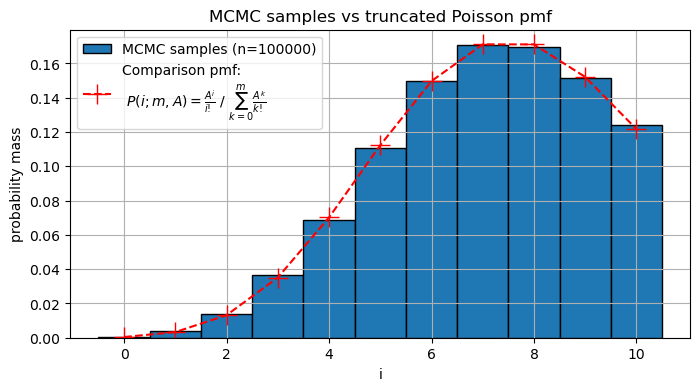

In [9]:
#Plot results
fig, ax = plt.subplots(figsize=(8,4))

#Edges for histogram bins
edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

#Histogram
ax.hist(
    X, 
    bins=edges,
    density=True,
    edgecolor='black',
    label= f"MCMC samples (n={n_sample:.0f})"
)

xgrid = np.arange(0,m+1)

#Evaluate pmf
pmf_vals = np.array([
    truncated_poisson_pmf(i, m, A)
    for i in range(0,m+1) 
])

plt.plot(
    xgrid,
    pmf_vals,
    label = ('Comparison pmf:\n'
             r' $P(i; m, A) = \frac{A^i}{i!} \ / \ \sum_{k=0}^{m} \frac{A^k}{k!}$'),
    color='red', 
    marker='+', 
    markersize=15, 
    linestyle='--'
)

ax.set_xlabel('i')
ax.set_ylabel('probability mass')
ax.set_title('MCMC samples vs truncated Poisson pmf')
ax.legend()
ax.grid()
plt.show()

In [10]:
### Function for chi2 p_val
def chi2_GOF(obs, exp, df):
    chi2_stat = np.sum( (obs-exp)**2 / exp )
    p_val = 1 - sp.stats.chi2.cdf(chi2_stat, df=df)
    return chi2_stat, p_val

### Function for grouping such that expected bins are always above 5
def group_bins(obs, exp, threshold=5):
    obs = np.asarray(obs)
    exp = np.asarray(exp)

    grouped_obs = []
    grouped_exp = []

    o_sum = 0
    e_sum = 0

    for o, e in zip(obs, exp):
        o_sum += o
        e_sum += e

        # close group when expected count is large enough
        if e_sum >= threshold:
            grouped_obs.append(o_sum)
            grouped_exp.append(e_sum)
            o_sum = 0
            e_sum = 0

    # handle leftover tail (important!)
    if e_sum > 0:
        grouped_obs[-1] += o_sum
        grouped_exp[-1] += e_sum

    return np.array(grouped_obs), np.array(grouped_exp)

In [12]:
### Chi2 Goodness-of-fit test: creating observed and expected bins
#Observed bins (number of bins: m+1)
obs = np.bincount(X, minlength=m+1)

#Expedted vals (using pmf)
exp = len(X)*pmf_vals

#Checking:
print("Before regrouping bins")
print(f"Number of bins: {len(exp)}")
print(f"Sum of obs: {sum(obs)}")
print(f"sum of exp: {sum(exp)}")
print("Observed values:")
print(obs)
print("Expected values:")
print(exp)
print("Is any expected val below 5? (if empty, then no):")
print(exp[exp<5])

### Apply grouping function
obs_g, exp_g = group_bins(obs=obs, exp=exp, threshold=5)

#Checking:
print("After regrouping bins")
print(f"Number of bins: {len(exp_g)}")
print(f"Sum of obs_g: {sum(obs_g)}")
print(f"sum of exp_g: {sum(exp_g)}")
print("Expected values after grouping:")
print(exp_g)
print("Is any expected val below 5? (if empty, then no):")
print(exp_g[exp_g<5])

Before regrouping bins
Number of bins: 11
Sum of obs: 100000
sum of exp: 99999.99999999999
Observed values:
[   46   368  1388  3635  6880 11048 14997 17083 16981 15168 12406]
Expected values:
[   41.11637082   328.93096653  1315.72386611  3508.59697629
  7017.19395258 11227.51032412 14970.0137655  17108.58716057
 17108.58716057 15207.63303162 12166.1064253 ]
Is any expected val below 5? (if empty, then no):
[]
After regrouping bins
Number of bins: 11
Sum of obs_g: 100000
sum of exp_g: 99999.99999999999
Expected values after grouping:
[   41.11637082   328.93096653  1315.72386611  3508.59697629
  7017.19395258 11227.51032412 14970.0137655  17108.58716057
 17108.58716057 15207.63303162 12166.1064253 ]
Is any expected val below 5? (if empty, then no):
[]


In [13]:
### Chi2 Goodness-of-fit test: perfomrning test
df = len(exp_g) - 1
print(f"number of df: {df}")
chi2_stat, p_val = chi2_GOF(obs=obs_g, exp=exp_g, df=df)

print("chi2 test statistic:")
print(chi2_stat)
print("p_val:")
print(p_val)

number of df: 10
chi2 test statistic:
25.16904107319498
p_val:
0.005034135686529662


## Part 2

For two different call types, the joint number of occupied lines is given by:

$$ P(i,j) = c\frac{A_1^i}{i!} \frac{A_2^j}{j!},  \quad  0\leq i+j \leq m $$

Use $A_1=A_2=4, \quad m=10$

For the above distribution, $P(i,j)$, complete:

a) Use the Metropolis-Hastings algorithm directly to generate samples from the distribution.

b) Use coordinatewise Metropolis-Hastings to generate samples from the distribution.

c) Use Gibbs sampling to generate samples from the distribution.
Determine the required conditional distributions analytically and use them in the Gibbs sampler.
In all three cases, assess the fit using a χ2 goodness-of-fit test.
Remark: The model can easily be extended to higher dimensions and additional restrictions on the different call types can be incorporated.

We choose again
$h(x,y) = uniform(0,m)$   
since this is symmetric.

We note that:

$f(i,j)=c\frac{A_1^i}{i!} \frac{A_2^j}{j!}$   
and   
$g(i,j)=\frac{A_1^i}{i!} \frac{A_2^j}{j!}$

The sample space is   
$X_k=(i,j)_k $   
where   
$i,j \in [0,m]$

The exact pmf distribution is taken as given truncated Poisson dist, normalised by all possibilites
$$ P(i,j; m, A_1, A_2) = \frac{\frac{A_1^i}{i!} \frac{A_2^j}{j!}}{\sum_{k=0}^{m} \sum_{l=0}^{m-k} \frac{A_1^k}{k!} \frac{A_2^l}{l!}} $$

In [14]:
#Define theoretical pmf
def truncated_poisson_joint_pmf(i, j, m, A_1, A_2):
    #normalisation of dist
    norm = 0
    for k in range(0,m+1):
        for l in range(0, m+1-k):
            norm += (A_1**k / math.factorial(k))*(A_2**l / math.factorial(l))
        
    numerator = (A_1**i / math.factorial(i))*(A_2**j / math.factorial(j))
    return numerator/norm

### a) 

Use the Metropolis-Hastings algorithm directly to generate samples from the distribution.

In [16]:
#Define g(x) function from f(x)=c*g(x)
def g_density_joint(i, j, A_1, A_2):
    fac1 = A_1**i / math.factorial(i)
    fac2 = A_2**j / math.factorial(j)
    return fac1*fac2

#Define function for combinations
def combinations_joint(m):
    # Make a list of all possible (i,j) combinations, when 0 <= i+j <= m
    # Number of combinations (discrete 2D simplex):  (m+1)*(m+2)/2 
    pairs = []
    for i in range(m+1):
        for j in range(m+1-i):
            pairs.append((i,j))
    return pairs

#Define proposal function
def h_proposal_joint(pairs):
    """
    input:
        comb (list):    list of tuples of (i,j) combinations
    """
    #Draw random idx to choose between pairs (from uniform dist)
    ran_idx = sp.stats.randint.rvs(low=0,high=len(pairs))
    i_val = pairs[ran_idx][0]
    j_val = pairs[ran_idx][1]
    return [i_val, j_val]

In [18]:
### Metropolis-Hastings algorithm for joint Erlang system (system following truncating Poisson distribution)
def MH_joint_erlang_sys(n_sample, m, A_1, A_2):
    #Convert to int
    n_sample = int(n_sample)

    #Initialise list of combinations of (i,j) given m-values
    pairs = combinations_joint(m)

    ## Step 0)
    #Initialise list for samples
    X = []
    #Initialise state x=(i,j) from proposal function, h(x,y)
    x = h_proposal_joint(pairs)
    X.append(x)

    #Acceptance counter
    accept_count = 0

    #start timing
    start1 = time.time()
    ## Start loop
    for _ in range(n_sample - 1):
        ## Step 1)
        #Start from current state
        x = X[-1]
        #Propose candidate state
        y = h_proposal_joint(pairs)

        ## Step 2)
        #Compute acceptance probability to go from x -> y
        g_y = g_density_joint(y[0], y[1], A_1=A_1, A_2=A_2)
        g_x = g_density_joint(x[0], x[1], A_1=A_1, A_2=A_2)
        alpha = min(1, g_y / g_x)

        #Decide by RNG whether proposal is accepted or rejected
        ## Step 3)
        #If accepted, move to y
        if sp.stats.uniform.rvs() <= alpha:
            X.append(y)
            #Count acceptance
            accept_count += 1
        ## Step 4)
        #Otherwise, remain at x (append x again)
        else:
            X.append(x)

    #end timing
    end1 = time.time()
    runtime1 = end1-start1
    
    return np.array(X), accept_count, runtime1

In [19]:
### Set params
n_sample = 1e5
m = 10
#A (offered traffic). Value from ex.
A_1 = 4
A_2 = 4

### Run simlation
X_joint, acc_joint, runtime_joint = MH_joint_erlang_sys(n_sample=n_sample, m=m, A_1=A_1, A_2=A_2)

In [20]:
#Check values
print("Sahpe of samples", np.shape(X_joint))
print("min val: ",min(X), " max val: ", max(X))
print(f"Acceptance rate: {acc_joint/n_sample:.3f}")
print(f"runtime: {runtime_joint:.2f} s")

Sahpe of samples (100000, 2)
min val:  0  max val:  10
Acceptance rate: 0.480
runtime: 15.45 s


In [21]:
# Compute theoretical distribution on grid
P = np.zeros((m+1, m+1))
for i in range(m+1):
    for j in range(m+1-i):
        P[i,j] = truncated_poisson_joint_pmf(i, j, m, A_1, A_2)

In [29]:
#Define theoretical marginal pmf from joint pmf

def truncated_poisson_marginal_pmf(i, m, A_1, A_2):
    sum = 0
    for j in range(m+1-i):
        sum += truncated_poisson_joint_pmf(i=i, j=j, m=m, A_1=A_1, A_2=A_2)
    return sum

#Evaluate marginal pmf
xgrid = np.arange(0,m+1)
marg_pmf_vals = np.array([
    truncated_poisson_marginal_pmf(i, m, A_1, A_2)
    for i in range(0,m+1) 
])

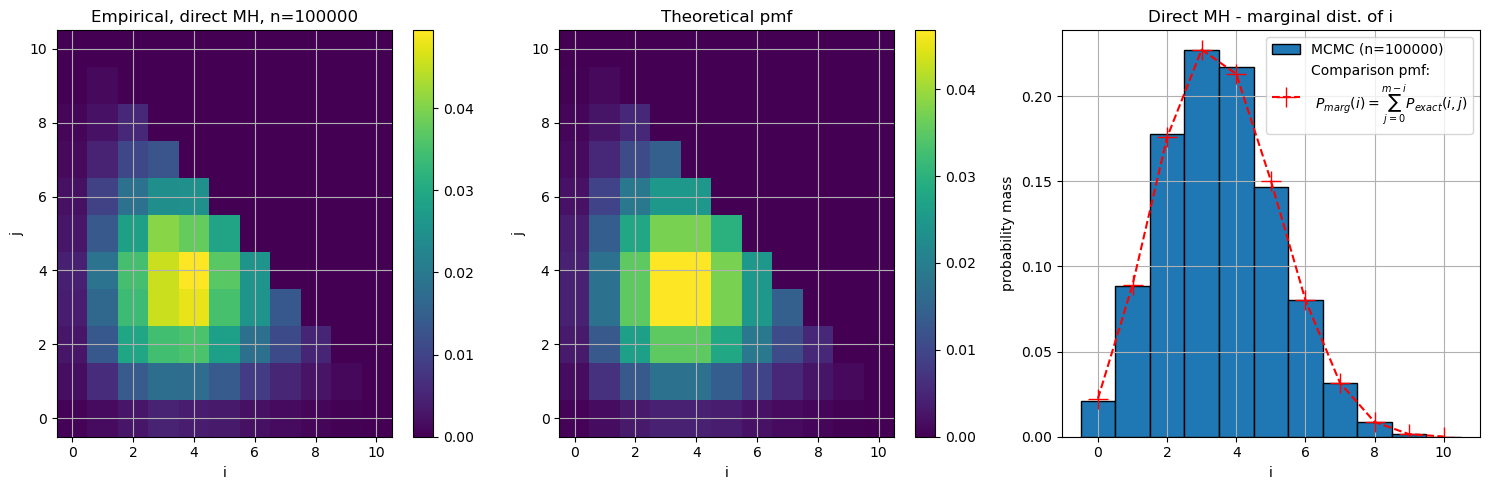

In [46]:
### All plots in 1

### PLotting joint dstribution
i_vals = X_joint[:,0]
j_vals = X_joint[:,1]

#Edges for histogram bins
edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

#Initialise fig, ax
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Compute 2D histogram
Histogram, _, _ = np.histogram2d(i_vals, j_vals, bins=edges, density=True)

### Plot emperical heatmap
im0 = ax[0].imshow(
    Histogram.T, 
    origin='lower',
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
    aspect='auto'
)
ax[0].set_title(f"Empirical, direct MH, n={n_sample:.0f}")
ax[0].set_xlabel("i")
ax[0].set_ylabel("j")
ax[0].grid()
fig.colorbar(im0, ax=ax[0])

### Plot theoretical heatmap
im1 = ax[1].imshow(
    P.T,
    origin='lower',
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
    aspect='auto'
)
ax[1].set_title(r"Theoretical pmf")
ax[1].set_xlabel("i")
ax[1].set_ylabel("j")
ax[1].grid()
fig.colorbar(im1, ax=ax[1])

#Histogram
ax[2].grid()
ax[2].hist(
    i_vals, 
    bins=edges,
    density=True,
    edgecolor='black',
    label= f"MCMC (n={n_sample:.0f})"
)
ax[2].plot(
    xgrid,
    marg_pmf_vals,
    label = ('Comparison pmf:\n'
             r' $P_{marg}(i) = \sum_{j=0}^{m-i} P_{exact}(i,j)$'),
    color='red', 
    marker='+', 
    markersize=15, 
    linestyle='--'
)

ax[2].set_xlabel('i')
ax[2].set_ylabel('probability mass')
ax[2].set_title('Direct MH - marginal dist. of i')
ax[2].legend()

plt.tight_layout()
plt.show()

In [67]:
### Chi2 Goodness-of-fit test: creating observed and expected bins
#Observed bins (number of bins: m+1)
obs = np.bincount(i_vals, minlength=m+1)

#Expedted vals (using pmf)
exp = len(i_vals)*marg_pmf_vals

#Checking:
print("Before regrouping bins")
print(f"Sum of obs: {sum(obs)}")
print(f"sum of exp: {sum(exp)}")
print("Observed values:")
print(obs)
print("Expected values:")
print(exp)
print("Is any expected val below 5? (if empty, then no):")
print(exp[exp<5])

### Apply grouping function
obs_g, exp_g = group_bins(obs=obs, exp=exp, threshold=5)

#Checking:
print("After regrouping bins")
print(f"number of bins: {len(exp_g)}")
print(f"Sum of obs_g: {sum(obs_g)}")
print(f"sum of exp_g: {sum(exp_g)}")
print("Expected values after grouping:")
print(exp_g)
print("Is any expected val below 5? (if empty, then no):")
print(exp_g[exp_g<5])

Before regrouping bins
Sum of obs: 100000
sum of exp: 99999.99999999999
Observed values:
[ 2231  8806 17449 22879 21081 15230  8116  3181   867   148    12]
Expected values:
[2.23850285e+03 8.90648757e+03 1.75753559e+04 2.27209500e+04
 2.12952344e+04 1.50401857e+04 8.03078863e+03 3.16330648e+03
 8.68795442e+02 1.48512041e+02 1.18809633e+01]
Is any expected val below 5? (if empty, then no):
[]
After regrouping bins
number of bins: 11
Sum of obs_g: 100000
sum of exp_g: 99999.99999999999
Expected values after grouping:
[2.23850285e+03 8.90648757e+03 1.75753559e+04 2.27209500e+04
 2.12952344e+04 1.50401857e+04 8.03078863e+03 3.16330648e+03
 8.68795442e+02 1.48512041e+02 1.18809633e+01]
Is any expected val below 5? (if empty, then no):
[]


In [48]:
### Chi2 Goodness-of-fit test: performning test
df = len(exp_g) - 1
print(f"number of df: {df}")
chi2_stat, p_val = chi2_GOF(obs=obs_g, exp=exp_g, df=df)

print("chi2 test statistic:")
print(chi2_stat)
print("p_val:")
print(p_val)

number of df: 10
chi2 test statistic:
30.334960186156074
p_val:
0.0007549535771018689


### b) 

Use coordinatewise Metropolis-Hastings to generate samples from the distribution.

In [49]:
### Metropolis-Hastings algorithm for Erlang system - Coordinate-wise MH sampling
# Change: proposal now happens in each direction seperately, i.e. proposal function from 1D case used
# but i+j=m constrain enforced always
# Acceptance prob. still calculated from joint distribution

def MH_joint_erlang_sys_coord(n_sample, m, A_1, A_2):
    #Convert to int
    n_sample = int(n_sample)

    #Initialise list of combinations of (i,j) given m-values
    pairs = combinations_joint(m)

    ## Step 0)
    #Initialise list for samples
    X = []
    #Initialise state x=(i,j) from proposal function, h(x,y)
    x = h_proposal_joint(pairs)
    X.append(x)

    #Acceptance counter
    accept_count = 0
    #Start timing
    start1 = time.time()

    ## Start loop
    for _ in range(n_sample - 1):
        
        #Start from current state
        x = X[-1]

        ## Step 1)
        ## ---i coordinate---
        #Propose i-coord of candidate state (nb: i = m-j)
        i_prop = h_proposal(m-x[1])
        y = [i_prop, x[1]]

        ## Step 2)
        #Compute acceptance probability to go from x -> y
        g_y = g_density_joint(y[0], y[1], A_1=A_1, A_2=A_2)
        g_x = g_density_joint(x[0], x[1], A_1=A_1, A_2=A_2)
        alpha = min(1, g_y / g_x)

        ## Step 3)
        #If accepted, change i-coord
        if sp.stats.uniform.rvs() <= alpha:
            x = y
            #Count acceptance
            accept_count += 1
        ## Step 4)
        #Otherwise, don't change i-coord
        
        ## Step 1)
        ## ---j coordinate---
        #Propose j-coord of candidate state (nb: j=m-i)
        j_prop = h_proposal(m-x[0])
        y = [x[0], j_prop]

        ## Step 2)
        #Compute acceptance probability to go from x -> y
        g_y = g_density_joint(y[0], y[1], A_1=A_1, A_2=A_2)
        g_x = g_density_joint(x[0], x[1], A_1=A_1, A_2=A_2)
        alpha = min(1, g_y / g_x)

        ## Step 3)
        #If accepted, change j-coord
        if sp.stats.uniform.rvs() <= alpha:
            x = y
            #Count acceptance
            accept_count += 1
        ## Step 4)
        #Otherwise, don't change j-coord

        ## Save state after both update attempts
        X.append(x)
    
    #end timing
    end1 = time.time()
    runtime1 = end1-start1
    
    return np.array(X), accept_count, runtime1

In [50]:
### Set params
n_sample = 1e5
m = 10
#A (offered traffic). Value from ex.
A_1 = 4
A_2 = 4

### Run simlation
X_joint_coord, acc_joint_coord, runtime_joint_coord = MH_joint_erlang_sys_coord(n_sample=n_sample, m=m, A_1=A_1, A_2=A_2)

In [51]:
print("Size", len(X_joint_coord))
print("min val: ",min(X), " max val: ", max(X))
print(f"Acceptance rate: {acc_joint_coord/(n_sample*2):.3f}")
print(f"runtime: {runtime_joint_coord:.2f} s")

Size 100000
min val:  0  max val:  10
Acceptance rate: 0.696
runtime: 25.80 s


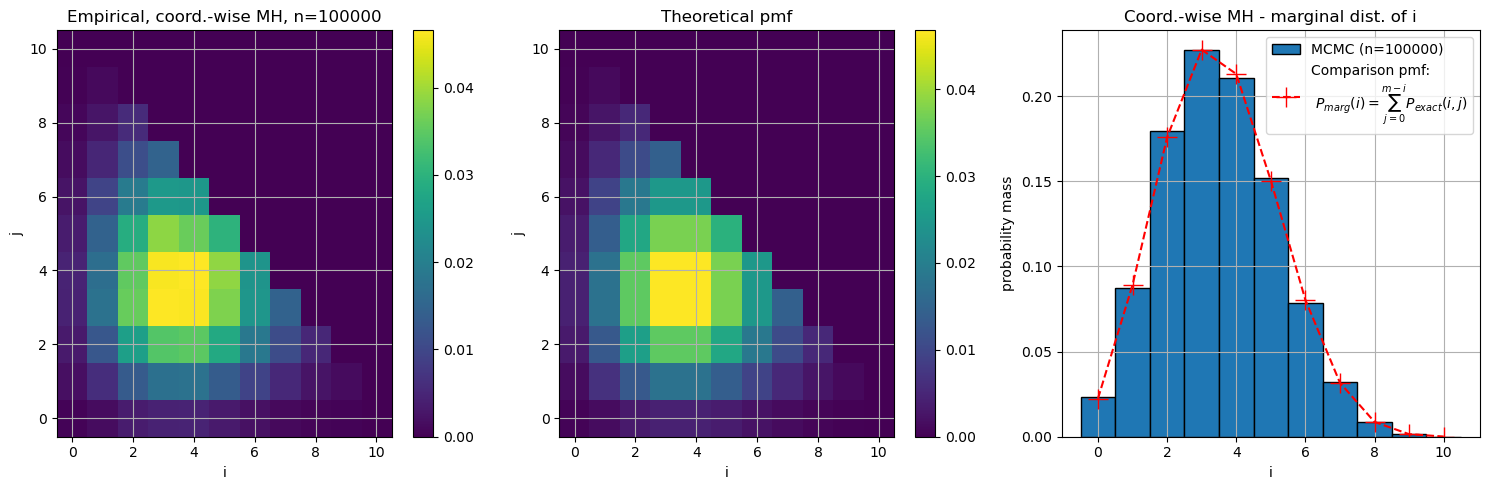

In [57]:
### All plots in 1

### PLotting joint dstribution
i_vals = X_joint_coord[:,0]
j_vals = X_joint_coord[:,1]

#Edges for histogram bins
edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

#Initialise fig, ax
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Compute 2D histogram
Histogram, _, _ = np.histogram2d(i_vals, j_vals, bins=edges, density=True)

### Plot emperical heatmap
im0 = ax[0].imshow(
    Histogram.T, 
    origin='lower',
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
    aspect='auto'
)
ax[0].set_title(f"Empirical, coord.-wise MH, n={n_sample:.0f}")
ax[0].set_xlabel("i")
ax[0].set_ylabel("j")
ax[0].grid()
fig.colorbar(im0, ax=ax[0])

### Plot theoretical heatmap
im1 = ax[1].imshow(
    P.T,
    origin='lower',
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
    aspect='auto'
)
ax[1].set_title(r"Theoretical pmf")
ax[1].set_xlabel("i")
ax[1].set_ylabel("j")
ax[1].grid()
fig.colorbar(im1, ax=ax[1])

#Histogram
ax[2].grid()
ax[2].hist(
    i_vals, 
    bins=edges,
    density=True,
    edgecolor='black',
    label= f"MCMC (n={n_sample:.0f})"
)
ax[2].plot(
    xgrid,
    marg_pmf_vals,
    label = ('Comparison pmf:\n'
             r' $P_{marg}(i) = \sum_{j=0}^{m-i} P_{exact}(i,j)$'),
    color='red', 
    marker='+', 
    markersize=15, 
    linestyle='--'
)

ax[2].set_xlabel('i')
ax[2].set_ylabel('probability mass')
ax[2].set_title('Coord.-wise MH - marginal dist. of i')
ax[2].legend()

plt.tight_layout()
plt.show()

In [54]:
### Chi2 Goodness-of-fit test: creating observed and expected bins
#Observed bins (number of bins: m+1)
obs = np.bincount(i_vals, minlength=m+1)

#Expedted vals (using pmf)
exp = len(i_vals)*marg_pmf_vals

#Checking:
print("Before regrouping bins")
print(f"Sum of obs: {sum(obs)}")
print(f"sum of exp: {sum(exp)}")
print("Observed values:")
print(obs)
print("Expected values:")
print(exp)
print("Is any expected val below 5? (if empty, then no):")
print(exp[exp<5])

### Apply grouping function
obs_g, exp_g = group_bins(obs=obs, exp=exp, threshold=5)

#Checking:
print("After regrouping bins")
print(f"Sum of obs_g: {sum(obs_g)}")
print(f"sum of exp_g: {sum(exp_g)}")
print("Expected values after grouping:")
print(exp_g)
print("Is any expected val below 5? (if empty, then no):")
print(exp_g[exp_g<5])

Before regrouping bins
Sum of obs: 100000
sum of exp: 99999.99999999999
Observed values:
[ 2341  8752 17933 22683 21061 15159  7848  3199   839   172    13]
Expected values:
[2.23850285e+03 8.90648757e+03 1.75753559e+04 2.27209500e+04
 2.12952344e+04 1.50401857e+04 8.03078863e+03 3.16330648e+03
 8.68795442e+02 1.48512041e+02 1.18809633e+01]
Is any expected val below 5? (if empty, then no):
[]
After regrouping bins
Sum of obs_g: 100000
sum of exp_g: 99999.99999999999
Expected values after grouping:
[2.23850285e+03 8.90648757e+03 1.75753559e+04 2.27209500e+04
 2.12952344e+04 1.50401857e+04 8.03078863e+03 3.16330648e+03
 8.68795442e+02 1.48512041e+02 1.18809633e+01]
Is any expected val below 5? (if empty, then no):
[]


In [55]:
### Chi2 Goodness-of-fit test: performning test
df = len(exp_g) - 1
print(f"number of df: {df}")
chi2_stat, p_val = chi2_GOF(obs=obs_g, exp=exp_g, df=df)

print("chi2 test statistic:")
print(chi2_stat)
print("p_val:")
print(p_val)

number of df: 10
chi2 test statistic:
27.634207530546423
p_val:
0.002065269889971133


### c)

c) Use Gibbs sampling to generate samples from the distribution.
Determine the required conditional distributions analytically and use them in the Gibbs sampler.

The conditional probabilities:

$$ P(i|j) = \frac{A_1^i}{i!}\left( \sum_{k=0}^{m-j} \frac{A_1^k}{k!} \right)^{-1}$$

and

$$ P(j|i) = \frac{A_2^j}{j!}\left( \sum_{k=0}^{m-i} \frac{A_2^k}{k!} \right)^{-1}$$



In [58]:
### Defining conditional probabilities
def P_i_given_j(j, m, A_1):   
    #Generate un-normalised probabilities
    probs = np.array([
        A_1**k / math.factorial(k) for k in range(m-j+1)
    ])
    #Normalise probabilities
    probs /= np.sum(probs)
    return probs

def P_j_given_i(i, m, A_2):
    #Generate un-normalised probabilities
    probs = np.array([
        A_2**k / math.factorial(k) for k in range(m-i+1)
    ])
    #Normalise probabilities
    probs /= np.sum(probs)
    return probs

In [59]:
### Gibbs sampling algorithm for Erlang system 
# Change: sampling  happens in each direction seperately, i+j=m constrain enforced always
# No rejection, sampling happens from conditional probabilities 

def Gibbs_joint_erlang_sys(n_sample, m, A_1, A_2):
    #Convert to int
    n_sample = int(n_sample)

    #Initialise list of combinations of (i,j) given m-values
    pairs = combinations_joint(m)

    ## Step 0)
    #Initialise list for samples
    X = []
    #Initialise state x=(i,j) from proposal function, h(x,y) (uniform from all (i,j) combinations)
    x = h_proposal_joint(pairs)
    X.append(x)

    #Start timing
    start1 = time.time()

    ## Start loop
    for _ in range(n_sample - 1):
        
        #Start from current state
        i,j = X[-1]

        ## 1) Sample new i given j
        #Generate probabilities via P(i|j)
        probs_i_given_j = P_i_given_j(j=j, m=m, A_1=A_1)
        #Draw i from this distribution (using np.random.choice)
        i = np.random.choice(range(m - j + 1), p=probs_i_given_j)

        ## 2) Sample new j given i
        #Generate probabilities via P(j|i)
        probs_j_given_i = P_j_given_i(i=i, m=m, A_2=A_2)
        #Draw i from this distribution (using np.random.choice)
        j = np.random.choice(range(m - i + 1), p=probs_j_given_i)

        ## Save state after both updates
        X.append([i, j])
    
    #end timing
    end1 = time.time()
    runtime1 = end1-start1
    
    return np.array(X), runtime1

In [60]:
### Set params
n_sample = 1e5
m = 10
#A (offered traffic). Value from ex.
A_1 = 4
A_2 = 4

### Run simlation
X_joint_gibbs, runtime_joint_gibbs = Gibbs_joint_erlang_sys(n_sample=n_sample, m=m, A_1=A_1, A_2=A_2)

In [61]:
#Check values
print("Sahpe of samples", np.shape(X_joint_gibbs))
print("min val: ",np.min(X_joint_gibbs), " max val: ", np.max(X_joint_gibbs))
print(f"runtime: {runtime_joint_gibbs:.2f} s")

Sahpe of samples (100000, 2)
min val:  0  max val:  10
runtime: 14.32 s


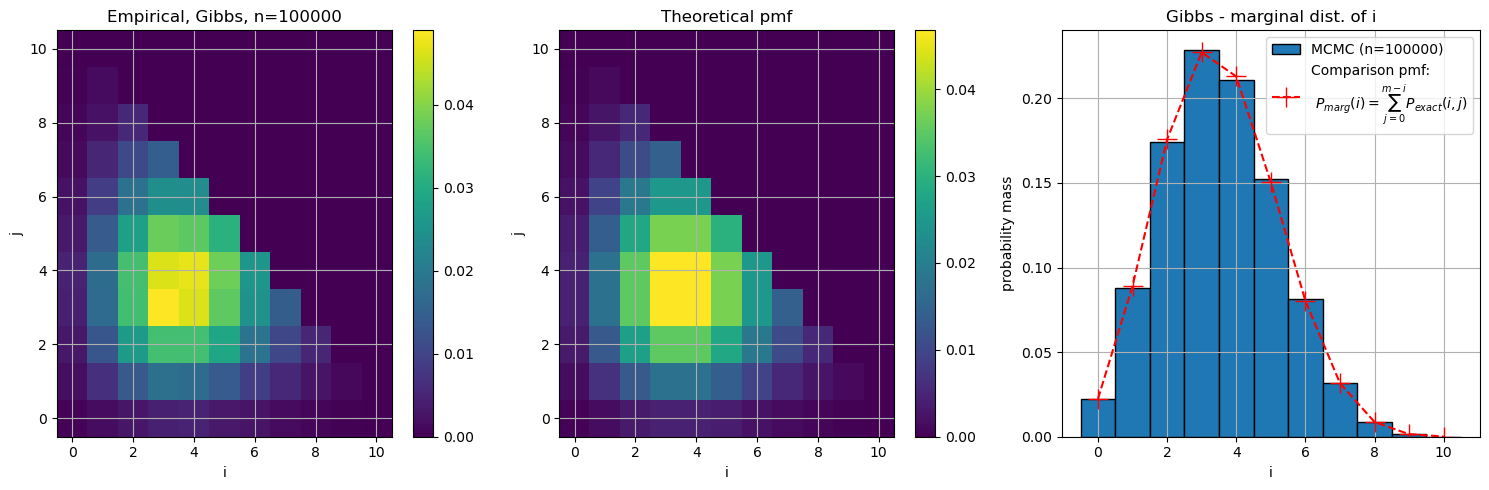

In [68]:
### All plots in 1

### PLotting joint dstribution
i_vals = X_joint_gibbs[:,0]
j_vals = X_joint_gibbs[:,1]

#Edges for histogram bins
edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

#Initialise fig, ax
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Compute 2D histogram
Histogram, _, _ = np.histogram2d(i_vals, j_vals, bins=edges, density=True)

### Plot emperical heatmap
im0 = ax[0].imshow(
    Histogram.T, 
    origin='lower',
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
    aspect='auto'
)
ax[0].set_title(f"Empirical, Gibbs, n={n_sample:.0f}")
ax[0].set_xlabel("i")
ax[0].set_ylabel("j")
ax[0].grid()
fig.colorbar(im0, ax=ax[0])

### Plot theoretical heatmap
im1 = ax[1].imshow(
    P.T,
    origin='lower',
    extent=[edges[0], edges[-1], edges[0], edges[-1]],
    aspect='auto'
)
ax[1].set_title(r"Theoretical pmf")
ax[1].set_xlabel("i")
ax[1].set_ylabel("j")
ax[1].grid()
fig.colorbar(im1, ax=ax[1])

#Histogram
ax[2].grid()
ax[2].hist(
    i_vals, 
    bins=edges,
    density=True,
    edgecolor='black',
    label= f"MCMC (n={n_sample:.0f})"
)
ax[2].plot(
    xgrid,
    marg_pmf_vals,
    label = ('Comparison pmf:\n'
             r' $P_{marg}(i) = \sum_{j=0}^{m-i} P_{exact}(i,j)$'),
    color='red', 
    marker='+', 
    markersize=15, 
    linestyle='--'
)

ax[2].set_xlabel('i')
ax[2].set_ylabel('probability mass')
ax[2].set_title('Gibbs - marginal dist. of i')
ax[2].legend()

plt.tight_layout()
plt.show()

In [65]:
### Chi2 Goodness-of-fit test: creating observed and expected bins
#Observed bins (number of bins: m+1)
obs = np.bincount(i_vals, minlength=m+1)

#Expedted vals (using pmf)
exp = len(i_vals)*marg_pmf_vals

#Checking:
print("Before regrouping bins")
print(f"Sum of obs: {sum(obs)}")
print(f"sum of exp: {sum(exp)}")
print("Observed values:")
print(obs)
print("Expected values:")
print(exp)
print("Is any expected val below 5? (if empty, then no):")
print(exp[exp<5])

### Apply grouping function
obs_g, exp_g = group_bins(obs=obs, exp=exp, threshold=5)

#Checking:
print("After regrouping bins")
print(f"Sum of obs_g: {sum(obs_g)}")
print(f"sum of exp_g: {sum(exp_g)}")
print("Expected values after grouping:")
print(exp_g)
print("Is any expected val below 5? (if empty, then no):")
print(exp_g[exp_g<5])

Before regrouping bins
Sum of obs: 100000
sum of exp: 99999.99999999999
Observed values:
[ 2231  8806 17449 22879 21081 15230  8116  3181   867   148    12]
Expected values:
[2.23850285e+03 8.90648757e+03 1.75753559e+04 2.27209500e+04
 2.12952344e+04 1.50401857e+04 8.03078863e+03 3.16330648e+03
 8.68795442e+02 1.48512041e+02 1.18809633e+01]
Is any expected val below 5? (if empty, then no):
[]
After regrouping bins
Sum of obs_g: 100000
sum of exp_g: 99999.99999999999
Expected values after grouping:
[2.23850285e+03 8.90648757e+03 1.75753559e+04 2.27209500e+04
 2.12952344e+04 1.50401857e+04 8.03078863e+03 3.16330648e+03
 8.68795442e+02 1.48512041e+02 1.18809633e+01]
Is any expected val below 5? (if empty, then no):
[]


In [70]:
x=np.array([0,1,2,3,4,5,6,7,8,9])

x[1::5]

array([1, 6])

In [66]:
### Chi2 Goodness-of-fit test: performning test
df = len(exp_g) - 1
print(f"number of df: {df}")
chi2_stat, p_val = chi2_GOF(obs=obs_g, exp=exp_g, df=df)

print("chi2 test statistic:")
print(chi2_stat)
print("p_val:")
print(p_val)

number of df: 10
chi2 test statistic:
8.727302820590781
p_val:
0.5581643513536834


## Part 2

## Part 3

### a)

Generate a sample (θ , ψ) from the prior distribution by first generating a sample
(ξ , γ) from (Ξ, Γ)

In [337]:
# Define parameters for bi-variate normal dist.
mu_Xi = 0
mu_Gam = 0
var_Xi = 1
var_Gam =1
rho = 0.5

mu = np.array([mu_Xi, mu_Gam])
cov_mat = np.array([[1, rho], [rho, 1]])

#Draw (xi,gamma) sample from distribution
np.random.seed(43)

xi, gamma = sp.stats.multivariate_normal.rvs(mean=mu, cov=cov_mat)

print(f"xi: {xi:.4f}")
print(f"gamma: {gamma:.4f}")

#Transform into (theta, psi) by log-relation
theta_true = np.exp(xi)
psi_true = np.exp(gamma)

print(f"theta: {theta_true:.4f}")
print(f"psi: {psi_true:.4f}")


xi: 0.2313
gamma: -0.6772
theta: 1.2603
psi: 0.5081


### b)

Using the generated values (θ , ψ), simulate observations X1, . . . , Xn with n = 10

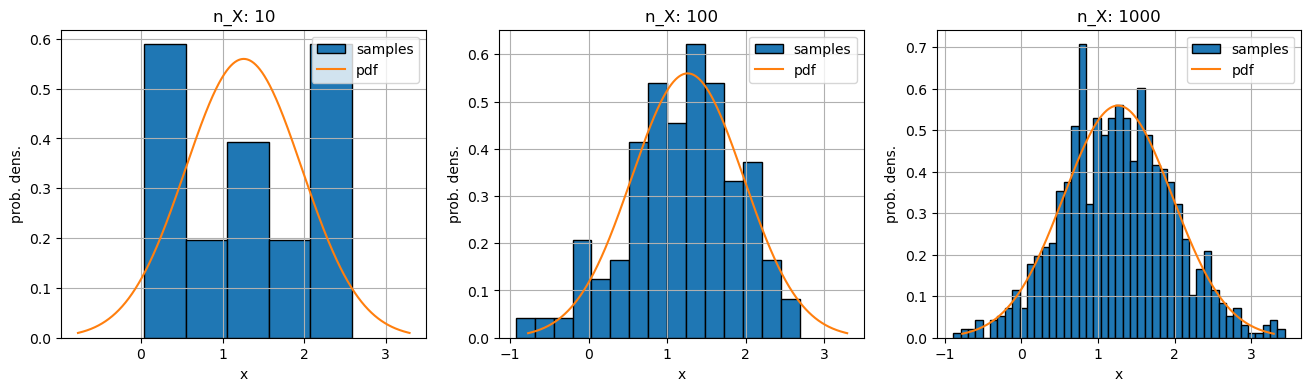

In [418]:
#Draw samples, X, from normal dist., using (theta,psi) as (mean,variance) 
n_samples1 = 10
n_samples2 = 100
n_samples3 = 1000

xgrid = np.linspace(theta_true-4*psi_true, theta_true+4*psi_true, 1000)
#NB: in scipy.stats.norm: scale is std dev = sqrt(var)
norm_vals = sp.stats.norm.pdf(x=xgrid, loc=theta_true, scale=np.sqrt(psi_true))

np.random.seed(44)
X_samples1 = sp.stats.norm.rvs(loc=theta_true, scale=np.sqrt(psi_true), size=n_samples1)
X_samples2 = sp.stats.norm.rvs(loc=theta_true, scale=np.sqrt(psi_true), size=n_samples2)
X_samples3 = sp.stats.norm.rvs(loc=theta_true, scale=np.sqrt(psi_true), size=n_samples3)

#Visualise samples and underlying dist
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16,4))

ax[0].hist(X_samples1, bins=5, edgecolor='black', label='samples', density=True)
ax[0].plot(xgrid, norm_vals, label='pdf')
ax[0].set_title(f"n_X: {n_samples1}")

ax[1].hist(X_samples2, bins=15, edgecolor='black', label='samples', density=True)
ax[1].plot(xgrid, norm_vals, label='pdf')
ax[1].set_title(f"n_X: {n_samples2}")

ax[2].hist(X_samples3, bins=45, edgecolor='black', label='samples', density=True)
ax[2].plot(xgrid, norm_vals, label='pdf')
ax[2].set_title(f"n_X: {n_samples3}")

#For all plots
for i in range(3):
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('prob. dens.')
    ax[i].legend()
    ax[i].grid()

plt.show()

### c)

Derive the posterior distribution of (Θ, Ψ) given the observed sample.
Hint: Apply Bayes’ theorem in its density form

In [407]:
#Define likelihood, posterior, and factored function (their product)
def likelihood(theta, psi, mean, var, n):
    """
    mean and var are sample mean and variance
    n is sample size 
    """
    power = - ((n-1)*var + n*(mean-theta)**2)/(2*psi)
    return psi**(-n/2)*np.exp(power)

def prior(theta, psi, rho):
    """
    rho is correlation between Xi and Gamma
    """
    power = - ( np.log(theta) - 2*rho*np.log(theta)*np.log(psi) + np.log(psi) ) / (2*( 1-rho**2 )) 
    return 1/(theta*psi) * np.exp(power)
    
#Only this one used
def g_post(theta, psi, rho, mean, var, n):
    power1 = - ((n-1)*var + n*(mean-theta)**2)/(2*psi)
    power2 = - ( np.log(theta) - 2*rho*np.log(theta)*np.log(psi) + np.log(psi) ) / (2*( 1-rho**2 )) 

    return 1/(psi**(n/2 + 1)*theta) * np.exp(power1 + power2)

#Only this one used
def g_post_log(theta, psi, rho, mean, var, n):
    power1 = - ((n-1)*var + n*(mean-theta)**2)/(2*psi)
    power2 = - ( np.log(theta) - 2*rho*np.log(theta)*np.log(psi) + np.log(psi) ) / (2*( 1-rho**2 )) 

    return -(n/2 + 1)*np.log(psi) - np.log(theta) + (power1 + power2)

### d)
Generate samples from the posterior distribution using the Metropolis-Hastings
algorithm

In [408]:
### Define proposal distribution: bivariate normal distribution centred around current values. No correlation
# absolute values (reflected values)
#Use this one
def h_proposal_post(theta, psi, rho=0):
    mu = np.array([theta, psi])
    cov_mat = np.array([[1, rho], [rho, 1]])
    #Make proposal 
    theta_prop, psi_prop = sp.stats.multivariate_normal.rvs(mean=mu, cov=cov_mat)
    #(and take abs val)
    return np.abs(theta_prop), np.abs(psi_prop) 

# Define 2nd proposal dist.: uniform for both params on [0,10]
def h_proposal_post2(upper_bound=10):
    return upper_bound*sp.stats.uniform.rvs(size=2)

In [ ]:
###FOR INSPIRATION
### Metropolis-Hastings algorithm for sampling posterior. 
# Using bi-variate normal dist (no corr) as proposal -_> random walk
def MH_posterior(n_new_samples, n_OG_samples, mean, var, rho):
    
    #Initialise list for samples
    X = []  

    ## Step 0)
    #Initialise state x=(theta,psi)  at (4 ,4)
    theta = 4
    psi = 4
    X.append([theta, psi])

    #Acceptance counter
    accept_count = 0
    #Start timing
    start1 = time.time()

    ## Start loop
    for _ in range(n_new_samples - 1):
        
        #Start from current state
        theta, psi = X[-1]

        ## Step 1)
        #Propose (theta,psi)-vals of candidate state
        theta_prop, psi_prop = h_proposal_post(theta=theta, psi=psi)
        #theta_prop, psi_prop = h_proposal_post2()

        ## Step 2)
        #Compute acceptance probability to go from old -> propopsed state
        #g_y = g_post(theta=theta_prop, psi=psi_prop, rho=rho, mean=mean, var=var, n=n_OG_samples)
        #g_x = g_post(theta=theta, psi=psi, rho=rho, mean=mean, var=var, n=n_OG_samples)
        g_y_log = g_post_log(theta=theta_prop, psi=psi_prop, rho=rho, mean=mean, var=var, n=n_OG_samples)
        g_x_log = g_post_log(theta=theta, psi=psi, rho=rho, mean=mean, var=var, n=n_OG_samples)
        #alpha = min(1, g_y / g_x)
        alpha = min(1, np.exp(g_y_log-g_x_log))
        ## Step 3)
        #If accepted, update state and count acceptance
        if sp.stats.uniform.rvs() <= alpha:
            theta = theta_prop
            psi = psi_prop
            accept_count += 1
        ## Step 4)
        #Otherwise, don't update state

        ## Save state after update attempt
        X.append([theta, psi])
    
    #end timing
    end1 = time.time()
    runtime1 = end1-start1

    return np.array(X), accept_count, runtime1

In [419]:
### Set params
n_new_samples = int(1e4)

mean_samp1 = np.mean(X_samples1)
var_samp1 = np.var(X_samples1, ddof=1)
mean_samp2 = np.mean(X_samples2)
var_samp2 = np.var(X_samples2, ddof=1)
mean_samp3 = np.mean(X_samples3)
var_samp3 = np.var(X_samples3, ddof=1)

print(f"true theta (mean): {theta_true:.3f}")
print(f"true psi (var): {psi_true:.3f}")
print(f"correlation betw. Xi and Gamma (rho): {rho:.2f}")

print(f"n_X1 samples drawn: {n_samples1}")
print(f"sample mean: {mean_samp1:.3f}")
print(f"sample var: {var_samp1:.3f}")
print(f"n_X2 samples drawn: {n_samples2}")
print(f"sample mean: {mean_samp2:.3f}")
print(f"sample var: {var_samp2:.3f}")
print(f"n_X3 samples drawn: {n_samples3}")
print(f"sample mean: {mean_samp3:.3f}")
print(f"sample var: {var_samp3:.3f}")

### Run simlation
X_MH_post_samples1, acc_post1, runtime_post1 = MH_posterior(n_new_samples=n_new_samples, 
                                                       n_OG_samples=n_samples1, mean=mean_samp1, 
                                                       var=var_samp1, rho=rho)
print("1 done")
X_MH_post_samples2, acc_post2, runtime_post2 = MH_posterior(n_new_samples=n_new_samples, 
                                                       n_OG_samples=n_samples2, mean=mean_samp2, 
                                                       var=var_samp2, rho=rho)
print("2 done")
X_MH_post_samples3, acc_post3, runtime_post3 = MH_posterior(n_new_samples=n_new_samples, 
                                                       n_OG_samples=n_samples3, mean=mean_samp3, 
                                                       var=var_samp3, rho=rho)
print("3 done")

true theta (mean): 1.260
true psi (var): 0.508
correlation betw. Xi and Gamma (rho): 0.50
n_X1 samples drawn: 10
sample mean: 1.223
sample var: 0.862
n_X2 samples drawn: 100
sample mean: 1.197
sample var: 0.497
n_X3 samples drawn: 1000
sample mean: 1.254
sample var: 0.511
1 done
2 done
3 done


In [ ]:

#Check values
theta_samples1 = X_MH_post_samples1[:,0]
psi_samples1 = X_MH_post_samples1[:,1]
theta_samples2 = X_MH_post_samples2[:,0]
psi_samples2 = X_MH_post_samples2[:,1]
theta_samples3 = X_MH_post_samples3[:,0]
psi_samples3 = X_MH_post_samples3[:,1]

print("Shape of samples", np.shape(X_MH_post_samples))
print("min val: ",np.min(X_MH_post_samples), " max val: ", np.max(X_MH_post_samples))
print(f"acceptance rate1: {acc_post1/n_new_samples}")
print(f"acceptance rate2: {acc_post2/n_new_samples}")
print(f"acceptance rate3: {acc_post3/n_new_samples}")
print(f"runtime1: {runtime_post1:.2f} s")
print(f"runtime2: {runtime_post2:.2f} s")
print(f"runtime3: {runtime_post3:.2f} s")

Shape of samples (20000, 2)
min val:  0.22864305149002714  max val:  4.0
acceptance rate1: 0.1621
acceptance rate2: 0.0128
acceptance rate3: 0.0024
runtime1: 3.78 s
runtime2: 3.50 s
runtime3: 4.75 s


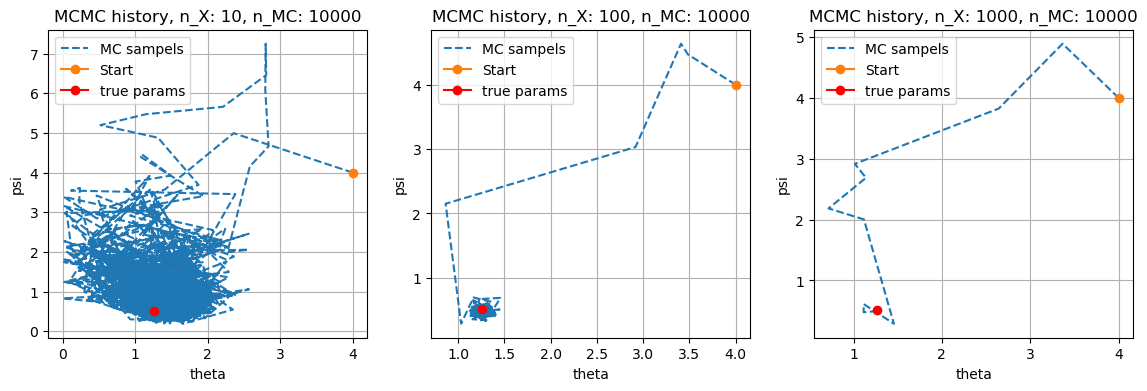

In [420]:
fig, ax =  plt.subplots(nrows=1, ncols=3, figsize=(14,4))


list_thetas = [theta_samples1, theta_samples2, theta_samples3]
list_psis = [psi_samples1, psi_samples2, psi_samples3]
list_nX = [n_samples1, n_samples2, n_samples3]

for i in range(3):
    theta_samples = list_thetas[i]
    psi_samples = list_psis[i]
    n_samples = list_nX[i]

    ax[i].plot(theta_samples, psi_samples, label='MC sampels', linestyle='dashed')
    ax[i].plot(theta_samples[0], psi_samples[0], label='Start', marker='o')
    ax[i].plot(theta_true, psi_true, color='red', label='true params', marker='o')
    ax[i].set_xlabel('theta')
    ax[i].set_ylabel('psi')
    ax[i].legend()
    ax[i].grid()
    ax[i].set_title(f'MCMC history, n_X: {n_samples}, n_MC: {n_new_samples}')

plt.show()

array([1.28493026, 1.28493026, 1.28493026, ..., 1.23452354, 1.23452354,
       1.23452354])

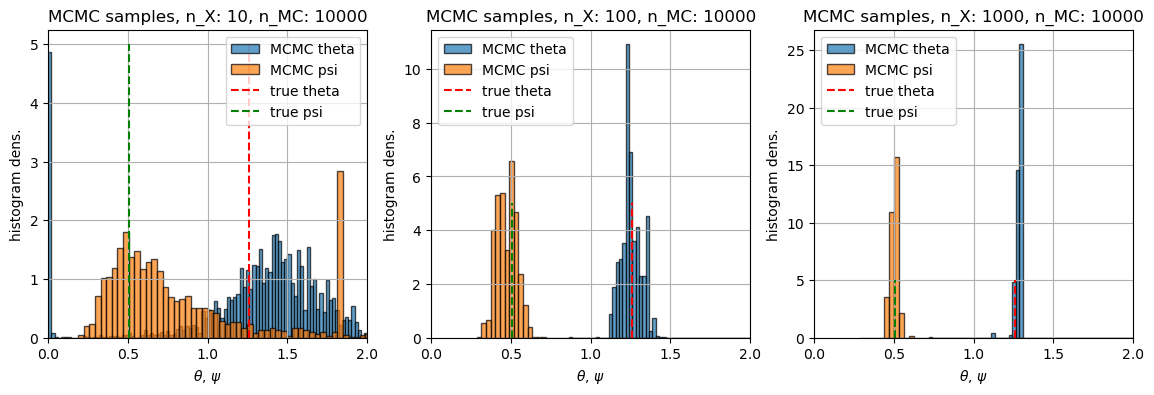

In [423]:
#Edges for histogram bins
#edges = np.linspace(start=-0.5, stop=m + 0.5, num=int(m+2))

list_nbins = [200, 150, 150]

#Plot results
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14,4))

for i in range(3):
    theta_samples = list_thetas[i]
    psi_samples = list_psis[i]
    n_samples = list_nX[i]
    n_bins = list_nbins[i]

    ax[i].grid()
    ax[i].hist(
        theta_samples, 
        bins=n_bins,
        density=True,
        edgecolor='black',
        label= f"MCMC theta",
        alpha=0.7
    )

    ax[i].hist(
        psi_samples, 
        bins=n_bins,
        density=True,
        edgecolor='black',
        label= f"MCMC psi",
        alpha=0.7
    )

    ax[i].vlines(theta_true, ymin=0, ymax=5, label='true theta', color='red', linestyle='--')
    ax[i].vlines(psi_true, ymin=0, ymax=5, label='true psi', color='green', linestyle='--')
    ax[i].set_xlim(0,2)
    ax[i].set_xlabel(r'$\theta$, $\psi$')
    ax[i].set_ylabel('histogram dens.')
    ax[i].set_title(f'MCMC samples, n_X: {n_samples}, n_MC: {n_new_samples}')
    ax[i].legend()

plt.show()


In [425]:
### Print sample mean of the estimated parameter

theta_MC_mean1 = np.mean(theta_samples1)
psi_MC_mean1 = np.mean(psi_samples1)
theta_MC_mean2 = np.mean(theta_samples2)
psi_MC_mean2 = np.mean(psi_samples2)
theta_MC_mean3 = np.mean(theta_samples3)
psi_MC_mean3 = np.mean(psi_samples3)


print(f"true theta (mean): {theta_true:.3f}")
print(f"true psi (var): {psi_true:.3f}")
print("results")
print(f"theta_MC_mean1: {theta_MC_mean1:.3f}")
print(f"psi_MC_mean1: {psi_MC_mean1:.3f}")
print(f"acceptance rate1: {acc_post1/n_new_samples}")
print(f"theta_MC_mean2: {theta_MC_mean2:.3f}")
print(f"psi_MC_mean2: {psi_MC_mean2:.3f}")
print(f"acceptance rate2: {acc_post2/n_new_samples}")
print(f"theta_MC_mean3: {theta_MC_mean3:.3f}")
print(f"psi_MC_mean3: {psi_MC_mean3:.3f}")
print(f"acceptance rate3: {acc_post3/n_new_samples}")

true theta (mean): 1.260
true psi (var): 0.508
results
theta_MC_mean1: 1.272
psi_MC_mean1: 0.872
acceptance rate1: 0.2242
theta_MC_mean2: 1.253
psi_MC_mean2: 0.476
acceptance rate2: 0.0211
theta_MC_mean3: 1.284
psi_MC_mean3: 0.514
acceptance rate3: 0.0025
